In [1]:
import os

import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde
from scipy.ndimage.filters import gaussian_filter

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MONDAY
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as mcolors
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

print("Package is ready.")

Package is ready.


In [2]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
raw_cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
raw_cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

In [3]:
def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

In [4]:
cmap = ['#e94d5b', '#f4a6ad', '#1bb1e7', '#25b575', '#f9a54f']
cmap_m = ['#f4a6ad', '#ffffff', '#86d6f2', '#8de7be', '#fccfa2']

In [5]:
cmap_rgb = []
for _ in cmap:
    ll = _.lstrip('#')
    cmap_rgb.append(tuple(int(ll[i:i+2], 16) for i in (0, 2, 4)))
cmap_m_rgb = []
for _ in cmap_m:
    ll = _.lstrip('#')
    cmap_m_rgb.append(tuple(int(ll[i:i+2], 16) for i in (0, 2, 4)))

In [6]:
N = 256
colmaps = []
for l in cmap_rgb:
    vals = np.ones((N, 4))
    vals[:, 0] = np.linspace(1, l[0]/256, N)
    vals[:, 1] = np.linspace(1, l[1]/256, N)
    vals[:, 2] = np.linspace(1, l[2]/256, N)
    colmaps.append(ListedColormap(vals))

In [7]:
# N = 256
# colmaps = []
# for l, ll in zip(cmap_rgb, cmap_m_rgb):
#     vals = np.ones((N, 4))
#     vals[:, 0] = np.linspace(ll[0]/256, l[0]/256, N)
#     vals[:, 1] = np.linspace(ll[1]/256, l[1]/256, N)
#     vals[:, 2] = np.linspace(ll[2]/256, l[2]/256, N)
#     colmaps.append(ListedColormap(vals))

# Graphical abstract

### Workflow for graph abstract

In [8]:
PAP_DIRECTORY = '../data/pap/'
file_list = os.listdir(PAP_DIRECTORY)
papset_list = [file for file in file_list if file.endswith('.csv')]
papset_list.sort()

In [9]:
pap_indices = []
for FILENAME in papset_list:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df.index = pd.DatetimeIndex(env_df.index)
    pap_indices.append([env_df.index[0], env_df.index[-1]])
pap_indices = np.array(pap_indices)

In [10]:
TOM_DIRECTORY = '../data/tom/'
file_list = os.listdir(TOM_DIRECTORY)
tomset_list = [file for file in file_list if file.endswith('.csv')]
tomset_list.sort()

In [11]:
tom_indices = []
for FILENAME in tomset_list:
    env_df = pd.read_csv(TOM_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df.index = pd.DatetimeIndex(env_df.index)
    tom_indices.append([env_df.index[0], env_df.index[-1]])
tom_indices = np.array(tom_indices)

In [12]:
temp_ = []
probs = [0.5, 0.6, 0.4, 0.8, 0.7]
for column, prob in zip(env_df.columns, probs):
    temp_.append(env_df[column].sample(frac=prob).reindex(env_df.index))
loss_df = pd.concat(temp_, axis=1)

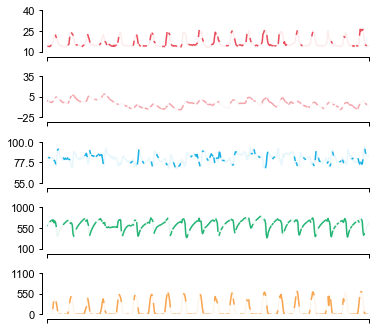

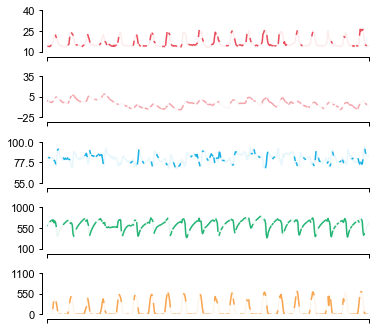

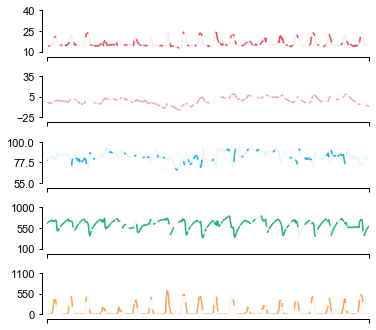

In [13]:
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [55, 100], [100, 1000], [0, 1100]]
for i in np.random.randint(55, size=3):
    fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
    grid = plt.GridSpec(5,1)
    for _ in range(5):
        ax = plt.subplot(grid[_])
        measured2 = ax.plot(x_t, env_df.values[:, _], c=cmap[_], alpha=0.1)
        measured1 = ax.plot(x_t, loss_df.values[:, _], c=cmap[_])
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 5))
        ax.spines['bottom'].set_position(('outward', 5))
        ax.set_xbound([24*i, 24*(i+20)])
        ax.set_ybound(Y_BOUNDS[_])
        ax.xaxis.set_major_locator(LinearLocator(2))
        ax.yaxis.set_major_locator(LinearLocator(3))
        ax.axes.xaxis.set_ticklabels([])

    fig.tight_layout()
    fig.savefig('./figures/GA_1_%02d.svg' % i, transparent=True, format='svg')
    plt.show()

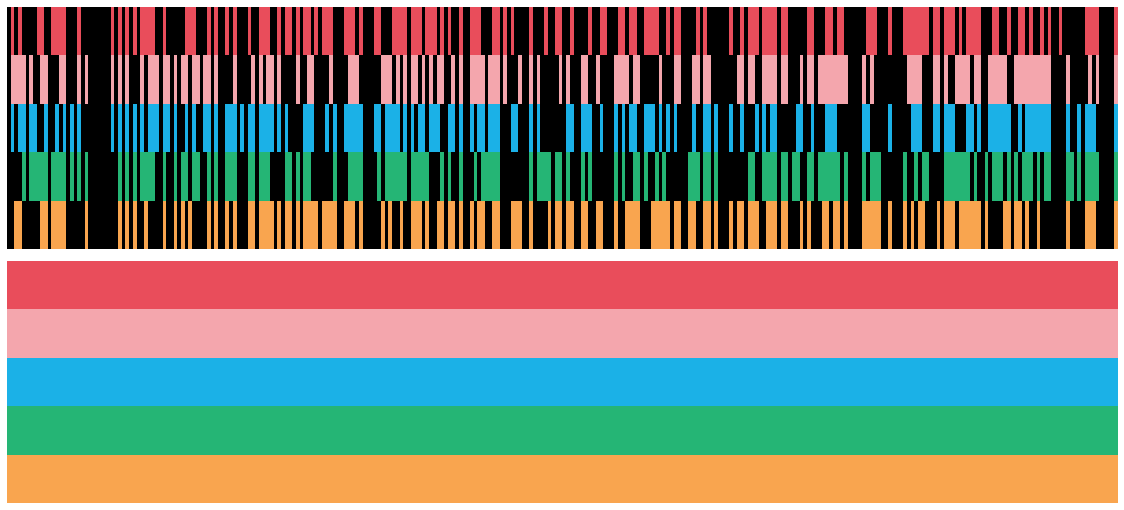

In [14]:
temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(10, 1)
fig = plt.figure(figsize=((8/2.54)*5, (6/2.54)*3*5))
for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.3]:
#         np.random.seed(3101)
        null_prob = 0.3
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
#         np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                       replace=False, size=int(env_df.shape[0] * raw_null_prob))

        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#000000', '#e94d5b', '#f4a6ad', '#1bb1e7', '#25b575', '#f9a54f'])
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df[:, 500:800], aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1

for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.0]:
#         np.random.seed(3101)
        null_prob = 0
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
#         np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                       replace=False, size=int(env_df.shape[0] * raw_null_prob))

        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#e94d5b', '#f4a6ad', '#1bb1e7', '#25b575', '#f9a54f'])
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df[:, 500:800], aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1
        
fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/GA_2.png', transparent=True, dpi=600, format='png')
plt.show()

# Figure 1

### Model structure

# Figure 2

### Data preparation process

# Figure 3

### (A) Data period & losses

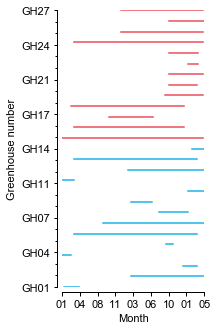

In [15]:
# maximum_x_values = pd.date_range(date_indices.min(), date_indices.max())
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
ax0 = plt.subplot()
i = 1
for DATES, ID in zip(pap_indices, papset_list):
    x_values = pd.date_range(DATES[0], DATES[-1])
    ax0.plot(DATES, ['GH' + ('%02d' % i)]*len(DATES), c=raw_cmap[4])
    i += 1

for DATES, ID in zip(tom_indices, tomset_list):
    x_values = pd.date_range(DATES[0], DATES[-1])
    ax0.plot(DATES, ['GH' + ('%02d' % i)]*len(DATES), c=raw_cmap[0])
    i += 1

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.xaxis.set_major_locator(LinearLocator(9))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m'))
ax0.set_xbound(pap_indices.min(), pap_indices.max() + pd.Timedelta('1h'))

ax0.yaxis.set_major_locator(LinearLocator(9))
ax0.yaxis.set_minor_locator(LinearLocator(25))
ax0.set_ybound('GH01', 'GH27')

ax0.set_xlabel('Month')
ax0.set_ylabel('Greenhouse number')


fig.tight_layout()
fig.savefig('./figures/Fig3A.svg', transparent=True, format='svg')
plt.show() 

### (B) Sampled data losses

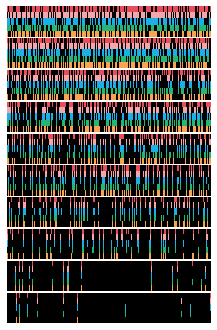

In [16]:
temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(10, 1)
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
#         np.random.seed(3101)
        null_prob = 0.3
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
#         np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                       replace=False, size=int(env_df.shape[0] * raw_null_prob))

        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap)
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3B.svg", transparent=True, format="svg")
plt.show()

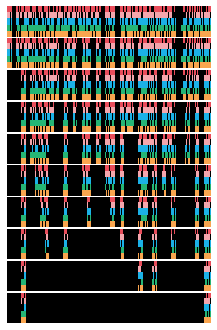

In [17]:
temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(10, 1)
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        np.random.seed(3101)
        null_prob = 0.3
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
        np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(int(env_df.shape[0]/48)-1),
                                       replace=False, size=int(env_df.shape[0]/48 * raw_null_prob))
        raw_indices = raw_indices*48
        raw_indices_ext = []
        for elem in raw_indices:
            for _ in range(elem, elem+48):
                raw_indices_ext.append(_)
        raw_indices = np.array(raw_indices_ext)
        raw_indices = np.unique(raw_indices[raw_indices < env_df.shape[0]])
        
        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap)
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3B.svg", transparent=True, format="svg")
plt.show()

# Figure 4

### One-to-one correspondence

In [18]:
fig_size = (8/2.54)*4.5*0.62*0.9, (6/2.54)*0.95*0.62*0.9
bounds = [[-15, 60], [-25, 40], [0, 110], [0, 3200], [-50, 1200]]
M_locators = [2]*5
m_locators = [5]*5
gammas = [0.1]*5
GS = 10
MC = 1

### U-Net

In [19]:
TOM_DIRECTORY = '../data/tom/'
file_list = os.listdir(TOM_DIRECTORY)
dataset_list = ['tom/' + file for file in file_list if file.endswith('.csv') and file.startswith('Val')]
dataset_list.sort()
temp = dataset_list

PAP_DIRECTORY = '../data/pap/'
file_list = os.listdir(PAP_DIRECTORY)
dataset_list = ['pap/' + file for file in file_list if file.endswith('.csv') and file.startswith('Val')]
dataset_list.sort()

temp.extend(dataset_list)
raw_dataset_list = temp

In [20]:
ORI_DIRECTORY = './results/'
file_list = os.listdir(ORI_DIRECTORY)
ori_dataset_list = [file for file in file_list if file.startswith('original') and file.endswith('UNet.csv')]
ori_dataset_list.sort()

In [21]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('UNet.csv')]
res_dataset_list.sort()

0.31994803151754403
5.440122899581547
[[0.38500407]] [13.78188614]

0.4935756745431613
7.1565247354401045
[[0.57928493]] [7.41398057]

0.33081442314768117
11.02214578066459
[[0.41417936]] [55.01530736]

0.22995735846715382
141.3254384677622
[[0.28478712]] [325.3506842]

0.21701430586508152
210.02961728089468
[[0.31544883]] [133.79775533]



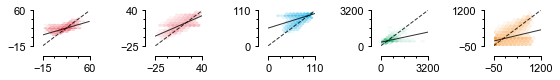

0.4476723213804793
4.903756729853263
[[0.53884998]] [9.81579371]

0.6931881351859177
5.570345308675489
[[0.79137088]] [3.87950484]

0.4885481624714997
9.632340960074332
[[0.65537162]] [30.30705305]

0.22655707567045935
141.60573859305362
[[0.44639805]] [240.51365336]

0.4056957557432106
182.91449823650075
[[0.46949987]] [74.62029906]



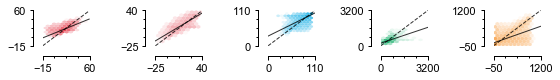

In [22]:
for SIZE in [5, 10]:
    plot_labels = {}
    plot_preds = {}
    raw_df = pd.read_csv('../data/pap/PF_0000587_pap_env.csv', index_col='MEAS_DATE')
    for COL in raw_df.columns:
        plot_labels[COL] = []
        plot_preds[COL] = []
    for original, recovery in zip([_ for _ in ori_dataset_list if '0.30' in _], [_ for _ in res_dataset_list if '0.30p_%d_' % SIZE in _]):
        raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
        raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
        ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')[(SIZE+1):-(SIZE+1)]
        try:
            res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
        except ValueError:
            res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
        raw_df.index = pd.DatetimeIndex(raw_df.index)
        ori_df.index = pd.DatetimeIndex(ori_df.index)
        res_df.index = pd.DatetimeIndex(res_df.index)
        
        raw_df = raw_df.where(ori_df.isnull())
        res_df = res_df.mask(raw_df.isnull())
        
        for COL in raw_df.columns:
            if len(res_df[COL].dropna()) == 0:
                continue
            else:
                plot_labels[COL].extend(raw_df[COL].dropna().values)
                plot_preds[COL].extend(res_df[COL].dropna().values)

    fig = plt.figure(figsize=fig_size)
    grid = plt.GridSpec(1,5)
    for i in range(5):
        target_label = np.array(plot_labels[raw_df.columns[i]]).reshape(-1, 1)
        target_pred = np.array(plot_preds[raw_df.columns[i]]).reshape(-1, 1)

        ax = plt.subplot(grid[i])
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 10))
        ax.spines['bottom'].set_position(('outward', 10))
        x_linear = np.arange(bounds[i][0], bounds[i][1])
        y_linear = x_linear
        regr = linear_model.LinearRegression()
        regr.fit(target_label, target_pred)
        Yp = regr.predict(target_label)
        reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
        reg_y = reg_x*regr.coef_ + regr.intercept_

        reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
        linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

        ax.hexbin(target_label, target_pred, linewidth=(0,), mincnt=MC, edgecolors='w', gridsize=GS, norm=mcolors.LogNorm(), cmap=colmaps[i])
#         ax.scatter(target_label, target_pred, linewidths=0.1, edgecolor='k', c=cmap[i], s=4, alpha=1, rasterized=True)        
#         ax.hist2d(target_label[:, 0], target_pred[:, 0], bins=(20, 20), norm=mcolors.LogNorm(), cmap=colmaps[i])
        ax.set_xbound(bounds[i])
        ax.set_ybound(bounds[i])
        ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
        ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
        print(r2_score(target_label, target_pred))
        print(np.sqrt(mean_squared_error(target_label, target_pred)))
        print(regr.coef_, regr.intercept_)
        print()

    fig.tight_layout()
    plt.subplots_adjust(hspace=0.05)
    fig.savefig('./figures/Fig4_UNet_%d.svg' % SIZE, transparent=True, format='svg')
    plt.show()

0.6694871724577139
3.794207801273637
[[0.6457232]] [7.53140492]

0.8709406979992453
3.614202023986727
[[0.86507841]] [1.19345696]

0.7489321988674954
6.747069999486398
[[0.7342931]] [23.98701851]

0.21104460227585187
142.9962034182012
[[0.69583319]] [236.86146864]

0.6883811524059754
132.40388361479933
[[0.75274793]] [56.14489373]



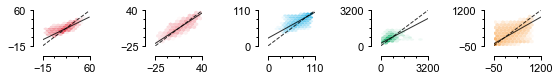

0.8001569192146536
2.9530002418293537
[[0.78011119]] [4.84682601]

0.9218248156916083
2.813681838184338
[[0.93819783]] [0.96433057]

0.8073728261014724
5.9081214616439315
[[0.83292213]] [14.46747795]

0.6649195079337518
93.19017169610056
[[0.70913038]] [138.99558269]

0.7875658398569854
109.39678949258004
[[0.8739917]] [25.92221849]



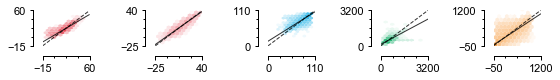

0.656713592865275
3.883780147095128
[[0.66122599]] [7.4174409]

0.8549835813972031
3.82960489541992
[[0.87971134]] [1.39843072]

0.5745837417933711
8.772778529520673
[[0.74313871]] [22.03603046]

0.23008613813066425
141.16834508529348
[[0.59572514]] [206.52956791]

0.6781899517839204
134.70823843562408
[[0.79711524]] [44.03704048]



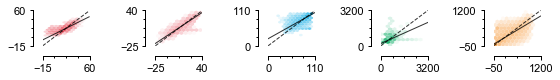

In [23]:
for SIZE in [20, 50, 100]:
    plot_labels = {}
    plot_preds = {}
    raw_df = pd.read_csv('../data/pap/PF_0000587_pap_env.csv', index_col='MEAS_DATE')
    for COL in raw_df.columns:
        plot_labels[COL] = []
        plot_preds[COL] = []
    for original, recovery in zip([_ for _ in ori_dataset_list if '0.30' in _], [_ for _ in res_dataset_list if '0.30p_%d' % SIZE in _]):
        raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
        raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
        ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')[(SIZE+1):-(SIZE+1)]
        try:
            res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
        except ValueError:
            res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
        raw_df.index = pd.DatetimeIndex(raw_df.index)
        ori_df.index = pd.DatetimeIndex(ori_df.index)
        res_df.index = pd.DatetimeIndex(res_df.index)
        
        raw_df = raw_df.where(ori_df.isnull())
        res_df = res_df.mask(raw_df.isnull())
        
        for COL in raw_df.columns:
            if len(res_df[COL].dropna()) == 0:
                continue
            else:
                plot_labels[COL].extend(raw_df[COL].dropna().values)
                plot_preds[COL].extend(res_df[COL].dropna().values)

    fig = plt.figure(figsize=fig_size)
    grid = plt.GridSpec(1,5)
    for i in range(5):
        target_label = np.array(plot_labels[raw_df.columns[i]]).reshape(-1, 1)
        target_pred = np.array(plot_preds[raw_df.columns[i]]).reshape(-1, 1)

        ax = plt.subplot(grid[i])
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 10))
        ax.spines['bottom'].set_position(('outward', 10))
        x_linear = np.arange(bounds[i][0], bounds[i][1])
        y_linear = x_linear
        regr = linear_model.LinearRegression()
        regr.fit(target_label, target_pred)
        Yp = regr.predict(target_label)
        reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
        reg_y = reg_x*regr.coef_ + regr.intercept_

        reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
        linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

        ax.hexbin(target_label, target_pred, linewidth=(0,), mincnt=MC, edgecolors='w', gridsize=GS, norm=mcolors.LogNorm(), cmap=colmaps[i])
        ax.set_xbound(bounds[i])
        ax.set_ybound(bounds[i])
        ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
        ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
        print(r2_score(target_label, target_pred))
        print(np.sqrt(mean_squared_error(target_label, target_pred)))
        print(regr.coef_, regr.intercept_)
        print()

    fig.tight_layout()
    plt.subplots_adjust(hspace=0.05)
    fig.savefig('./figures/Fig4_UNet_%d.svg' % SIZE, transparent=True, format='svg')
    plt.show()

### FFNN

In [24]:
bounds = [[-25, 75], [-85, 85], [0, 160], [-2000, 3200], [-1650, 2350]]
M_locators = [2]*5
m_locators = [5]*5
gammas = [0.2]*4 + [0.15]

In [25]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('FFNN.csv')]
res_dataset_list.sort()

-3.3442523105206217
13.816048659553813
[[0.24604738]] [19.23453845]

-14.805503900546787
39.98062280142235
[[0.32794432]] [-22.17696329]

-1.7368750970926827
22.251413939901376
[[0.06117877]] [97.20585379]

-85.31663871515127
1494.7326258025146
[[0.08370167]] [-950.52891448]

-14.253283122335684
927.4190714230178
[[0.35854766]] [-426.37235174]



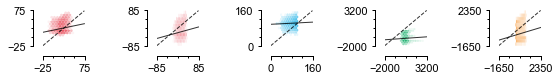

In [26]:
plot_labels = {}
plot_preds = {}
raw_df = pd.read_csv('../data/pap/PF_0000587_pap_env.csv', index_col='MEAS_DATE')
for COL in raw_df.columns:
    plot_labels[COL] = []
    plot_preds[COL] = []
for original, recovery in zip([_ for _ in ori_dataset_list if '0.30' in _], [_ for _ in res_dataset_list if '0.30' in _]):
    raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
    raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
    ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')[(SIZE+1):-(SIZE+1)]
    try:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
    except ValueError:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
    raw_df.index = pd.DatetimeIndex(raw_df.index)
    ori_df.index = pd.DatetimeIndex(ori_df.index)
    res_df.index = pd.DatetimeIndex(res_df.index)

    raw_df = raw_df.where(ori_df.isnull())
    res_df = res_df.mask(raw_df.isnull())

    for COL in raw_df.columns:
        if len(res_df[COL].dropna()) == 0:
            continue
        else:
            plot_labels[COL].extend(raw_df[COL].dropna().values)
            plot_preds[COL].extend(res_df[COL].dropna().values)

fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(1,5)
for i in range(5):
    target_label = np.array(plot_labels[raw_df.columns[i]]).reshape(-1, 1)
    target_pred = np.array(plot_preds[raw_df.columns[i]]).reshape(-1, 1)

    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    x_linear = np.arange(bounds[i][0], bounds[i][1])
    y_linear = x_linear
    regr = linear_model.LinearRegression()
    regr.fit(target_label, target_pred)
    Yp = regr.predict(target_label)
    reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
    reg_y = reg_x*regr.coef_ + regr.intercept_

    reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
    linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

    ax.hexbin(target_label, target_pred, linewidth=(0,), mincnt=MC, edgecolors='w', gridsize=GS, norm=mcolors.LogNorm(), cmap=colmaps[i])
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
    print(r2_score(target_label, target_pred))
    print(np.sqrt(mean_squared_error(target_label, target_pred)))
    print(regr.coef_, regr.intercept_)
    print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/Fig4_FFNN.svg', transparent=True, format='svg')
plt.show()

### RNN

In [27]:
bounds = [[-20, 60], [-30, 70], [0, 110], [-150, 3200], [-700, 1650]]
M_locators = [2]*5
m_locators = [5]*5
gammas = [0.2]*4 + [0.15]

In [28]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('RNN.csv')]
res_dataset_list.sort()

0.12963934697958968
6.184092235170899
[[0.16171378]] [17.28590789]

0.0712239038969803
9.691720849607291
[[0.15613584]] [10.6616221]

-0.037042033715736444
13.69708982342846
[[0.03837652]] [86.72765193]

0.02771947303510458
158.63976136230568
[[0.08183634]] [429.50128376]

-0.009325526356112057
238.5667890077184
[[0.12690176]] [148.58159236]



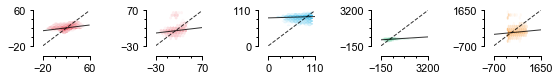

In [29]:
plot_labels = {}
plot_preds = {}
raw_df = pd.read_csv('../data/pap/PF_0000587_pap_env.csv', index_col='MEAS_DATE')
for COL in raw_df.columns:
    plot_labels[COL] = []
    plot_preds[COL] = []
for original, recovery in zip([_ for _ in ori_dataset_list if '0.30' in _], [_ for _ in res_dataset_list if '0.30' in _]):
    raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
    raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
    ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')[101:-101]
    try:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
    except ValueError:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
    raw_df.index = pd.DatetimeIndex(raw_df.index)
    ori_df.index = pd.DatetimeIndex(ori_df.index)
    res_df.index = pd.DatetimeIndex(res_df.index)

    raw_df = raw_df.where(ori_df.isnull())
    res_df = res_df.mask(raw_df.isnull())

    for COL in raw_df.columns:
        if len(res_df[COL].dropna()) == 0:
            continue
        else:
            plot_labels[COL].extend(raw_df[COL].dropna().values)
            plot_preds[COL].extend(res_df[COL].dropna().values)

fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(1,5)
for i in range(5):
    target_label = np.array(plot_labels[raw_df.columns[i]]).reshape(-1, 1)
    target_pred = np.array(plot_preds[raw_df.columns[i]]).reshape(-1, 1)

    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    x_linear = np.arange(bounds[i][0], bounds[i][1])
    y_linear = x_linear
    regr = linear_model.LinearRegression()
    regr.fit(target_label, target_pred)
    Yp = regr.predict(target_label)
    reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
    reg_y = reg_x*regr.coef_ + regr.intercept_

    reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
    linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

    ax.hexbin(target_label, target_pred, linewidth=(0,), mincnt=MC, edgecolors='w', gridsize=GS, norm=mcolors.LogNorm(), cmap=colmaps[i])
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
    print(r2_score(target_label, target_pred))
    print(np.sqrt(mean_squared_error(target_label, target_pred)))
    print(regr.coef_, regr.intercept_)
    print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/Fig4_RNN.svg', transparent=True, format='svg')
plt.show()

### Linear Interpolation

In [30]:
bounds = [[-20, 60], [-20, 60], [0, 110], [-150, 3200], [0, 1500]]
M_locators = [2]*5
m_locators = [5]*5
gammas = [0.2]*4 + [0.15]

In [31]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('LI.csv')]
res_dataset_list.sort()

0.7068651178654304
3.5710255507914983
[[0.79377943]] [2.61269566]

0.876052306804853
3.540831347406276
[[0.91729506]] [-0.18608215]

0.7614293477823961
6.5808691328464075
[[0.85184089]] [13.55434412]

0.6190345163825266
99.41854564672721
[[0.70418829]] [168.70474936]

0.1660518590361244
216.6881638668578
[[0.38909483]] [7.6726699]



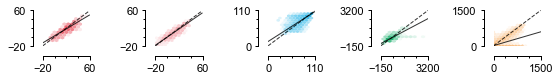

In [32]:
plot_labels = {}
plot_preds = {}
raw_df = pd.read_csv('../data/pap/PF_0000587_pap_env.csv', index_col='MEAS_DATE')
for COL in raw_df.columns:
    plot_labels[COL] = []
    plot_preds[COL] = []
for original, recovery in zip([_ for _ in ori_dataset_list if '0.30' in _], [_ for _ in res_dataset_list if '0.30' in _]):
    raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
    raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
    ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')
    try:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
    except ValueError:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
    raw_df.index = pd.DatetimeIndex(raw_df.index)
    ori_df.index = pd.DatetimeIndex(ori_df.index)
    res_df.index = pd.DatetimeIndex(res_df.index)

    raw_df = raw_df.where(ori_df.isnull())
    res_df = res_df.mask(raw_df.isnull())

    for COL in raw_df.columns:
        if len(res_df[COL].dropna()) == 0:
            continue
        else:
            plot_labels[COL].extend(raw_df[COL].dropna().values)
            plot_preds[COL].extend(res_df[COL].dropna().values)

fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(1,5)
for i in range(5):
    target_label = np.array(plot_labels[raw_df.columns[i]]).reshape(-1, 1)
    target_pred = np.array(plot_preds[raw_df.columns[i]]).reshape(-1, 1)

    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    x_linear = np.arange(bounds[i][0], bounds[i][1])
    y_linear = x_linear
    regr = linear_model.LinearRegression()
    regr.fit(target_label, target_pred)
    Yp = regr.predict(target_label)
    reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
    reg_y = reg_x*regr.coef_ + regr.intercept_

    reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
    linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

    ax.hexbin(target_label, target_pred, linewidth=(0,), mincnt=MC, edgecolors='w', gridsize=GS, norm=mcolors.LogNorm(), cmap=colmaps[i])
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
    print(r2_score(target_label, target_pred))
    print(np.sqrt(mean_squared_error(target_label, target_pred)))
    print(regr.coef_, regr.intercept_)
    print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/Fig4_LI.svg', transparent=True, format='svg')
plt.show()

# Figure 5

### Accruacy for various losses

In [33]:
LOSS_RATES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

In [34]:
TOM_DIRECTORY = '../data/tom/'
file_list = os.listdir(TOM_DIRECTORY)
dataset_list = ['tom/' + file for file in file_list if file.endswith('.csv') and file.startswith('Val')]
dataset_list.sort()
temp = dataset_list

PAP_DIRECTORY = '../data/pap/'
file_list = os.listdir(PAP_DIRECTORY)
dataset_list = ['pap/' + file for file in file_list if file.endswith('.csv') and file.startswith('Val')]
dataset_list.sort()

temp.extend(dataset_list)
raw_dataset_list = temp

In [35]:
ORI_DIRECTORY = './results/'
file_list = os.listdir(ORI_DIRECTORY)
ori_dataset_list = [file for file in file_list if file.startswith('original') and file.endswith('UNet.csv')]
ori_dataset_list.sort()

### U-Net

In [36]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('50_UNet.csv')]
res_dataset_list.sort()

In [37]:
target_labels = {}
target_preds = {}

raw_df = pd.read_csv('../data/pap/PF_0000587_pap_env.csv', index_col='MEAS_DATE')
for original in ori_dataset_list:
    target_labels['loss_%s' % (original.split('_')[-2])] = {}
    target_preds['loss_%s' % (original.split('_')[-2])] = {}
    for COL in raw_df.columns:
        target_labels['loss_%s' % (original.split('_')[-2])][COL] = []
        target_preds['loss_%s' % (original.split('_')[-2])][COL] = []
for original, recovery in zip(ori_dataset_list, res_dataset_list):
    raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
    raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
    ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')[51:-51]
    try:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
    except ValueError:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
    raw_df.index = pd.DatetimeIndex(raw_df.index)
    ori_df.index = pd.DatetimeIndex(ori_df.index)
    res_df.index = pd.DatetimeIndex(res_df.index)
    
    raw_df = raw_df.where(ori_df.isnull())
    res_df = res_df.mask(raw_df.isnull())
    raw_df = raw_df
    res_df = res_df

    for COL in raw_df.columns:
        if len(res_df[COL].dropna()) == 0:
            continue
        else:
            target_labels['loss_%s' % (original.split('_')[-2])][COL].extend(raw_df[COL].dropna().values)
            target_preds['loss_%s' % (original.split('_')[-2])][COL].extend(res_df[COL].dropna().values)

In [38]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    
    for COL in raw_df.columns:
        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL]))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL])))

In [39]:
UNet_R2_df = pd.DataFrame(R2_table)
UNet_R2_df[UNet_R2_df < 0] = 0
UNet_RMSE_df = pd.DataFrame(RMSE_table)

### LSTM

In [40]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('RNN.csv')]
res_dataset_list.sort()

In [41]:
target_labels = {}
target_preds = {}

for original in ori_dataset_list:
    target_labels['loss_%s' % (original.split('_')[-2])] = {}
    target_preds['loss_%s' % (original.split('_')[-2])] = {}
    for COL in raw_df.columns:
        target_labels['loss_%s' % (original.split('_')[-2])][COL] = []
        target_preds['loss_%s' % (original.split('_')[-2])][COL] = []
for original, recovery in zip(ori_dataset_list, res_dataset_list):
    raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
    raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')[101:-101]
    ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')
    try:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
    except ValueError:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
    raw_df.index = pd.DatetimeIndex(raw_df.index)
    ori_df.index = pd.DatetimeIndex(ori_df.index)
    res_df.index = pd.DatetimeIndex(res_df.index)
    
    raw_df = raw_df.where(ori_df.isnull())
    res_df = res_df.mask(raw_df.isnull())
    raw_df = raw_df
    res_df = res_df

    for COL in raw_df.columns:
        if len(res_df[COL].dropna()) == 0:
            continue
        else:
            target_labels['loss_%s' % (original.split('_')[-2])][COL].extend(raw_df[COL].dropna().values)
            target_preds['loss_%s' % (original.split('_')[-2])][COL].extend(res_df[COL].dropna().values)

In [42]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    
    for COL in raw_df.columns:
        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL]))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL])))

In [43]:
LSTM_R2_df = pd.DataFrame(R2_table)
LSTM_R2_df[LSTM_R2_df < 0] = 0
LSTM_RMSE_df = pd.DataFrame(RMSE_table)

### FFNN

In [44]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('FFNN.csv')]
res_dataset_list.sort()

In [45]:
target_labels = {}
target_preds = {}

for original in ori_dataset_list:
    target_labels['loss_%s' % (original.split('_')[-2])] = {}
    target_preds['loss_%s' % (original.split('_')[-2])] = {}
    for COL in raw_df.columns:
        target_labels['loss_%s' % (original.split('_')[-2])][COL] = []
        target_preds['loss_%s' % (original.split('_')[-2])][COL] = []
for original, recovery in zip(ori_dataset_list, res_dataset_list):
    raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
    raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
    ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')[1:-1]
    try:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
    except ValueError:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
    raw_df.index = pd.DatetimeIndex(raw_df.index)
    ori_df.index = pd.DatetimeIndex(ori_df.index)
    res_df.index = pd.DatetimeIndex(res_df.index)
    
    raw_df = raw_df.where(ori_df.isnull())
    res_df = res_df.mask(raw_df.isnull())
    raw_df = raw_df
    res_df = res_df

    for COL in raw_df.columns:
        if len(res_df[COL].dropna()) == 0:
            continue
        else:
            target_labels['loss_%s' % (original.split('_')[-2])][COL].extend(raw_df[COL].dropna().values)
            target_preds['loss_%s' % (original.split('_')[-2])][COL].extend(res_df[COL].dropna().values)

In [46]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    
    for COL in raw_df.columns:
        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL]))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL])))

In [47]:
FFNN_R2_df = pd.DataFrame(R2_table)
FFNN_R2_df[FFNN_R2_df < 0] = 0
FFNN_RMSE_df = pd.DataFrame(RMSE_table)

### Linear interpolation

In [48]:
RES_DIRECTORY = './results/'
file_list = os.listdir(RES_DIRECTORY)
res_dataset_list = [file for file in file_list if file.startswith('recovered') and file.endswith('LI.csv')]
res_dataset_list.sort()

In [49]:
target_labels = {}
target_preds = {}

for original in ori_dataset_list:
    target_labels['loss_%s' % (original.split('_')[-2])] = {}
    target_preds['loss_%s' % (original.split('_')[-2])] = {}
    for COL in raw_df.columns:
        target_labels['loss_%s' % (original.split('_')[-2])][COL] = []
        target_preds['loss_%s' % (original.split('_')[-2])][COL] = []
for original, recovery in zip(ori_dataset_list, res_dataset_list):
    raw = [_ for _ in raw_dataset_list if original.split('_')[3] in _][0]
    raw_df = pd.read_csv('../data/%s' % raw, index_col='MEAS_DATE')
    ori_df = pd.read_csv('./results/%s' % original, index_col='MEAS_DATE')
    try:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='Unnamed: 0')
    except ValueError:
        res_df = pd.read_csv('./results/%s' % recovery, index_col='MEAS_DATE')
    raw_df.index = pd.DatetimeIndex(raw_df.index)
    ori_df.index = pd.DatetimeIndex(ori_df.index)
    res_df.index = pd.DatetimeIndex(res_df.index)
    
    raw_df = raw_df.where(ori_df.isnull())
    res_df = res_df.mask(raw_df.isnull())
    raw_df = raw_df
    res_df = res_df

    for COL in raw_df.columns:
        if len(res_df[COL].dropna()) == 0:
            continue
        else:
            target_labels['loss_%s' % (original.split('_')[-2])][COL].extend(raw_df[COL].dropna().values)
            target_preds['loss_%s' % (original.split('_')[-2])][COL].extend(res_df[COL].dropna().values)

In [50]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    
    for COL in raw_df.columns:
        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL]))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_labels['loss_%.2fp' % LOSS_RATE][COL], target_preds['loss_%.2fp' % LOSS_RATE][COL])))

In [51]:
LI_R2_df = pd.DataFrame(R2_table)
LI_R2_df[LI_R2_df < 0] = 0
LI_RMSE_df = pd.DataFrame(RMSE_table)

In [52]:
fig_size = (8/2.54)*4.5*0.62, (6/2.54)*2*0.62
y_bounds = [[0, 50], [0, 60], [0, 120], [0, 2400], [0, 1200]]

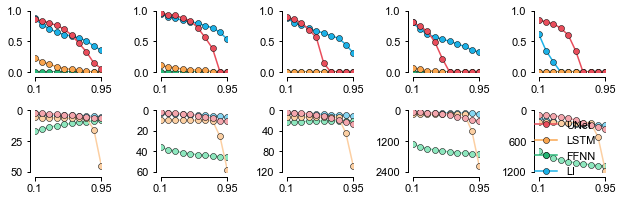

In [53]:
x_t = [str(_) for _ in LOSS_RATES]
fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(2,5)
for _ in range(5):
    ax = plt.subplot(grid[_])
    R2_4, = ax.plot(x_t, LI_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[4])
    R2_3, = ax.plot(x_t, FFNN_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[3])
    R2_2, = ax.plot(x_t, LSTM_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[2])
    R2_1, = ax.plot(x_t, UNet_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[0])
    
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    
    ax.set_xbound([x_t[0], x_t[-1]])
    ax.set_ybound([0, 1])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))

locates = [3, 4, 4, 3, 3]
x_t = [str(_) for _ in LOSS_RATES]
for _ in range(5):
    ax = plt.subplot(grid[_+5])    
    RMSE2_4, = ax.plot(x_t, LI_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[4])
    RMSE2_3, = ax.plot(x_t, FFNN_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[3])
    RMSE2_2, = ax.plot(x_t, LSTM_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[2])
    RMSE2_1, = ax.plot(x_t, UNet_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[0])
    
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.invert_yaxis()
    
    ax.set_xbound([x_t[0], x_t[-1]])
    ax.set_ybound(y_bounds[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(locates[_]))


plt.legend([R2_1, R2_2, R2_3, R2_4], ['UNet', 'LSTM', 'FFNN', 'LI'], frameon=False)
fig.tight_layout()
fig.savefig('./figures/Fig5.svg', transparent=True, format='svg')
plt.show()

# Table 1

### Ranges of data

In [54]:
MAXS = [-500]*5
MINS = [500]*5
for FILENAME in papset_list:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    for i in range(5):
#         if i == 3:
#             if env_df[:, i][env_df[:, i] >10].max(axis=0) > MAXS[i]:
#                 MAXS[i] = env_df[:, i][env_df[:, i] >0].max(axis=0)
#             if env_df[:, i][env_df[:, i] >10].min(axis=0) < MINS[i]:
#                 MINS[i] = env_df[:, i][env_df[:, i] >0].min(axis=0)
#                 if MINS[i] == 1.67:
#                     print(FILENAME)
#             continue
        if env_df.max(axis=0)[i] > MAXS[i]:
            MAXS[i] = env_df.max(axis=0)[i]
        if env_df.min(axis=0)[i] < MINS[i]:
            MINS[i] = env_df.min(axis=0)[i]
            
print(MAXS)
print(MINS)

[54.88, 37.35, 101.27, 2999.0, 1027.7]
[5.32, -21.18, 19.38, 1.67, 0.0]


In [55]:
MAXS = [-500]*5
MINS = [500]*5
for FILENAME in tomset_list:
    env_df = pd.read_csv(TOM_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    for i in range(5):
        if i == 3:
            if env_df[:, i][env_df[:, i] >10].max(axis=0) > MAXS[i]:
                MAXS[i] = env_df[:, i][env_df[:, i] >0].max(axis=0)
            if env_df[:, i][env_df[:, i] >10].min(axis=0) < MINS[i]:
                MINS[i] = env_df[:, i][env_df[:, i] >0].min(axis=0)
                if MINS[i] == 1.67:
                    print(FILENAME)
            continue
        if env_df.max(axis=0)[i] > MAXS[i]:
            MAXS[i] = env_df.max(axis=0)[i]
        if env_df.min(axis=0)[i] < MINS[i]:
            MINS[i] = env_df.min(axis=0)[i]

print(MAXS)
print(MINS)

[60.25, 37.95, 100.0, 2382.08, 1669.92]
[-10.14, -14.72, 5.86, 36.64, 0.0]


# Figure XX

### DISUSE

fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,1)
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [85, 100], [100, 1000], [0, 1100]]
COLOR_CODE = [0, 1, 4, 3, 2]
i=10
for _ in range(5):
    ax = plt.subplot(grid[_])
    measured1 = ax.plot(x_t, env_df.values[:, _], c=cmap[COLOR_CODE[_]])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([24*i, 24*(i+10)])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])

fig.tight_layout()
# fig.savefig('./figures/Fig1A.svg', transparent=True, format='svg')
# # fig.savefig('./figures/Fig6A.png', transparent=True, dpi=600, format='png')
plt.show()

fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,1)
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [85, 100], [100, 1000], [0, 1100]]
COLOR_CODE = [0, 1, 4, 3, 2]
i=20
for _ in range(5):
    ax = plt.subplot(grid[_])
    measured1 = ax.plot(x_t, env_df.values[:, _], c=cmap[COLOR_CODE[_]])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([24*i, 24*(i+10)])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])

fig.tight_layout()
# fig.savefig('./figures/Fig1B.svg', transparent=True, format='svg')
# # fig.savefig('./figures/Fig6A.png', transparent=True, dpi=600, format='png')
plt.show()

fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,1)
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [85, 100], [100, 1200], [0, 1100]]
COLOR_CODE = [0, 1, 4, 3, 2]
i=0
for _ in range(5):
    ax = plt.subplot(grid[_])
    measured1 = ax.plot(x_t, env_df.values[:, _], c=cmap[COLOR_CODE[_]])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([24*i, 24*(i+10)])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])

fig.tight_layout()
# fig.savefig('./figures/Fig1C.svg', transparent=True, format='svg')
# # fig.savefig('./figures/Fig6A.png', transparent=True, dpi=600, format='png')
plt.show()

### DISUSE

temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(27, 1)
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
for FILENAME in papset_list:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    np.random.seed(3101)
    null_prob = 0.3
    mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
    np.random.seed(4564)
    raw_null_prob = 0.5
    raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                   replace=False, size=int(env_df.shape[0] * raw_null_prob))
    
    mask[raw_indices, :] = 0
    missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                 [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

    ax0 = fig.add_subplot(gs[i])

    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.spines['bottom'].set_visible(False)

    colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap[:-1])

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.setp(ax.get_yticklabels(), visible=False)
    plt.axis('off')
    a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

    # ax1 = fig.add_subplot(gs[1])
    # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
    # ax1.spines['right'].set_visible(False)
    # ax1.spines['left'].set_position(('outward', 5))
    # ax1.spines['bottom'].set_position(('outward', 5))


    # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
    # x_pos = np.arange(len(x_label))
    # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
    # ax1.set_xticklabels(x_label)

    
    i += 1

for FILENAME in tomset_list:
    env_df = pd.read_csv(TOM_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    np.random.seed(3101)
    null_prob = 0.3
    mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
    np.random.seed(4564)
    raw_null_prob = 0.2
    raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                   replace=False, size=int(env_df.shape[0] * raw_null_prob))
    
    mask[raw_indices, :] = 0
    missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                 [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

    ax0 = fig.add_subplot(gs[i])

    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.spines['bottom'].set_visible(False)

    colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap[:-1])

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.setp(ax.get_yticklabels(), visible=False)
    plt.axis('off')
    a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

    # ax1 = fig.add_subplot(gs[1])
    # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
    # ax1.spines['right'].set_visible(False)
    # ax1.spines['left'].set_position(('outward', 5))
    # ax1.spines['bottom'].set_position(('outward', 5))


    # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
    # x_pos = np.arange(len(x_label))
    # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
    # ax1.set_xticklabels(x_label)

    
    i += 1

fig.tight_layout()
# plt.subplots_adjust(hspace=0.1)
# fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

### DISUSE

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
gammas = [0.05, 0.1, 0.06, 0.1, 0.05]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    ax.hist2d(target_label, target_pred, bins=100, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i], rasterized=True)
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
c#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
gammas = [0.05, 0.1, 0.06, 0.1, 0.05]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    heatmap, xedges, yedges = np.histogram2d(target_label, target_pred, bins=10)
#     heatmap = gaussian_filter(heatmap, sigma=32)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    
    ax.imshow(heatmap, extent=extent, origin='lower', cmap=colmaps[i])
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
gammas = [0.05, 0.1, 0.06, 0.1, 0.05]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

   
    ax.hist2d(target_label, target_pred, bins=30, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i], rasterized=True)
    
#     np.random.seed(7755)
#     target_label = np.random.choice(target_label, size=1000)
#     np.random.seed(7755)
#     target_pred = np.random.choice(target_pred, size=1000)
    ax.scatter(target_label, target_pred, linewidths=.1, edgecolors='k', c=cmap[i], s=4, alpha=0.5, rasterized=True)
    
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    np.random.seed(7755)
    np.random.choice(target_label, size=1000)
    np.random.seed(7755)
    np.random.choice(target_pred, size=1000)
    # Calculate the point density
    xy = np.vstack([target_label,target_pred])
    z = gaussian_kde(xy)(xy)

    # Sort the points by density, so that the densest points are plotted last
    idx = z.argsort()
    target_label, target_pred, z = target_label[idx], target_pred[idx], z[idx]
    
    ax.scatter(target_label, target_pred, c=z, s=4, alpha=.1)
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
#fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    ax.scatter(target_label, target_pred, linewidths=0.1, c=cmap[i], s=4, alpha=.1)
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
#fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

def bin_by(x, y, nbins=30, bins = None):
    """
    Divide the x axis into sections and return groups of y based on its x value
    """
    if bins is None:
        bins = np.linspace(x.min(), x.max(), nbins)

    bin_space = (bins[-1] - bins[0])/(len(bins)-1)/2

    indicies = np.digitize(x, bins + bin_space)

    output = []
    for i in range(0, len(bins)):
        output.append(y[indicies==i])
    #
    # prepare a dataframe with cols: median; mean; 1up, 1dn, 2up, 2dn, 3up, 3dn
    df_names = ['mean'] + ['%sth' % int(num) for num in range(5, 100, 5)]
    df = pd.DataFrame(columns = df_names)
    to_delete = []
    # for each bin, determine the std ranges
    for y_set in output:
        if y_set.size > 0:
            av = y_set.mean()
            intervals = np.percentile(y_set, q = [num for num in range(5, 100, 5)])
            res = [av] + list(intervals)
            df = df.append(pd.DataFrame([res], columns = df_names))
        else:
            # just in case there are no elements in the bin
            to_delete.append(len(df) + 1 + len(to_delete))
            

    # add x values
    bins = np.delete(bins, to_delete)
    df['x'] = bins

    return df

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]
    
    df = bin_by(target_label, target_pred, nbins=100, bins = None)
    for _ in range(5, 50, 5):
        plt.fill_between(df.x, df['%sth' % _], df['%sth' % (100-_)], alpha=0.5, color = cmap[i])
    # plt the line
    plt.plot(df.x, df['50th'], color =cmap[i], alpha = 1, linewidth = 1)
    # plot the points
    
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
#fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()